<div style="max-width:850px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:20px;border-right:10px solid #5e2ca5;border-left:10px solid #5e2ca5;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 8px 16px rgba(0,0,0,0.3);text-align:center;">
    <h1 style="color:#bc92ff;margin-top:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;font-size:2em;">Smoker Status Prediction</h1>
    <h3 style="color:#9d65ff;font-style:italic;margin-bottom:15px;font-size:1.2em;">SVM Classification &amp; Dimensionality Reduction</h3>
    <hr style="border:0;height:1px;background:linear-gradient(to right,transparent,#5e2ca5,transparent);margin:15px 0;">
    <p style="font-size:1.05em;line-height:1.6;color:#e1d5f2;padding:0 20px;">
        A complete data science lifecycle on the <b>Bio-Signals Smoking Dataset</b> (159K records, 23 features).
        Goal: predict whether a person is a smoker using <b>SVM</b> with <b>PCA</b> dimensionality reduction.
    </p>
</div>

<div style="max-width:1200px;margin:auto;background-color:#ffffff;padding:20px;border:2px solid #1a0f2e;border-radius:15px;box-shadow:5px 5px 0px #5e2ca5;">

<h2 style="color:#1a0f2e;margin-top:0;border-bottom:2px solid #5e2ca5;display:inline-block;font-size:1.5em;">
Project Roadmap
</h2>

<ul style="color:#2e1a47;line-height:1.8;font-size:1em;list-style-type:'💜 ';margin-top:10px;">
    <li><b>Phase 1:</b> Environment Setup & Data Acquisition.</li>
    <li><b>Phase 2:</b> Train/Test Split (Before Any Preprocessing).</li>
    <li><b>Phase 3:</b> Exploratory Data Analysis (EDA).</li>
    <li><b>Phase 4:</b> Data Cleaning & Preprocessing.</li>
    <li><b>Phase 5:</b> Dimensionality Reduction (PCA).</li>
    <li><b>Phase 6:</b> Hard & Soft-Margin SVM & Decision Boundary Visualization.</li>
    <li><b>Phase 7:</b> Model Evaluation (Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC Curve) to assess model performance and ensure reliable classification results.</li>
</ul>

</div>


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">1️⃣ — Phase 1: Environment Setup</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Imports & Configuration</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">Importing all required libraries for data manipulation, visualization, dimensionality reduction, and SVM modeling.</p>
</div>

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn: Preprocessing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-learn: Dimensionality Reduction ───────────────────────────────────
from sklearn.decomposition import PCA

# ── Scikit-learn: Evaluation ─────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

# ── Optimization ─────────────────────────────────────────────────────────────
from scipy.optimize import minimize

# ── Global Style & Color Constants ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
PURPLE      = '#bc92ff'
DARK_PURPLE = '#5e2ca5'
BG_COLOR    = '#1a0f2e'
LIGHT_BG    = '#d9bbdf'
COLORS      = ['#4B0082', '#8A2BE2', '#BA55D3', '#DDA0DD', '#E6E6FA']

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


<div style="max-width:1200px;margin:auto;background-color:#f8f5ff;padding:20px;border:2px solid #1a0f2e;border-radius:12px;border-left:8px solid #5e2ca5;">
    <h2 style="color:#1a0f2e;margin-top:0;display:flex;align-items:center;">
        <span style="background-color:#5e2ca5;color:white;padding:5px 15px;border-radius:8px;margin-right:10px;">📂</span>
        Load the Dataset
    </h2>
    <p style="color:#2e1a47;font-size:1.05em;line-height:1.6;margin-top:10px;">
        Loading the <b>Binary Prediction of Smoker Status</b> dataset from Kaggle Playground Series S3E24.
        The dataset contains <b>159,256 records</b> and <b>23 bio-signal features</b> per individual.
        The classification goal is to predict whether a person is a smoker (<code>smoking = 1</code>) or not (<code>smoking = 0</code>).
        <br><br>
        <b>Note:</b> The <code>id</code> column is dropped as it carries no predictive information.
    </p>
</div>

In [2]:
# Load dataset
df = pd.read_csv("D:\\الكلية\\تالتة\\الترم الثاني\\computation\\train.csv")

# Drop id column (no predictive value)
df = df.drop(columns=['id'])

# Preview
df.head()


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,55,165,60,81.0,0.5,0.6,1,1,135,87,...,40,75,16.5,1,1.0,22,25,27,0,1
1,70,165,65,89.0,0.6,0.7,2,2,146,83,...,57,126,16.2,1,1.1,27,23,37,1,0
2,20,170,75,81.0,0.4,0.5,1,1,118,75,...,45,93,17.4,1,0.8,27,31,53,0,1
3,35,180,95,105.0,1.5,1.2,1,1,131,88,...,38,102,15.9,1,1.0,20,27,30,1,0
4,30,165,60,80.5,1.5,1.0,1,1,121,76,...,44,93,15.4,1,0.8,19,13,17,0,1


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📊 Dataset Dimensions Inspection</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Total rows and columns.</p>
</div>

In [3]:
df.shape

(159256, 23)

<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🔍 Technical Metadata Summary</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Data types and non-null counts.</p>
</div>

<table style="width:100%; border-collapse: collapse; color: #e1d5f2; text-align: left; background-color: rgba(188, 146, 255, 0.05); border-radius: 15px; overflow: hidden; font-size: 0.95em;">
    <thead>
        <tr style="background-color: #4b2c85; color: #ffffff;">
            <th style="padding: 15px; border-bottom: 2px solid #bc92ff;">Category & Feature</th>
            <th style="padding: 15px; border-bottom: 2px solid #bc92ff;">Normal Range / Interpretation</th>
            <th style="padding: 15px; border-bottom: 2px solid #bc92ff;">Gender Specific</th>
        </tr>
    </thead>
    <tbody>
        <!-- Personal Measurements -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">👤 Personal Measurements</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Age</td>
            <td style="padding: 12px;">20 – 85 years</td>
            <td style="padding: 12px;">General population</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Height (cm)</td>
            <td style="padding: 12px;">Men: 160–185 | Women: 148–172</td>
            <td style="padding: 12px;">🚹 Men Avg: 174 / 🚺 Women Avg: 161</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Weight (kg)</td>
            <td style="padding: 12px;">Men: 60–90 | Women: 45–75</td>
            <td style="padding: 12px;">🚹 Men Avg: 75 / 🚺 Women Avg: 60</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Waist (cm)</td>
            <td style="padding: 12px;">Healthy: Men < 94 | Women < 80</td>
            <td style="padding: 12px;">High Risk: Men ≥102 / Women ≥88</td>
        </tr>
        <!-- Vision & Hearing -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">👁️ Vision & Hearing</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Eyesight (L/R)</td>
            <td style="padding: 12px;">Normal: 1.0+ | Impaired: < 0.5</td>
            <td style="padding: 12px;">No gender difference</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Hearing (L/R)</td>
            <td style="padding: 12px;">1 = Normal | 2 = Impaired</td>
            <td style="padding: 12px;">Binary categorical</td>
        </tr>
        <!-- Blood Pressure -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">🫀 Blood Pressure</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Systolic (mmHg)</td>
            <td style="padding: 12px;">Normal < 120 | Stage 2 Hypertension ≥ 140</td>
            <td style="padding: 12px;">Same for both genders</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Relaxation (mmHg)</td>
            <td style="padding: 12px;">Normal < 80 | Stage 2 ≥ 90</td>
            <td style="padding: 12px;">Diastolic pressure</td>
        </tr>
        <!-- Blood Tests -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">🩸 Blood Tests</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Fasting Sugar</td>
            <td style="padding: 12px;">Normal: < 100 mg/dL</td>
            <td style="padding: 12px;">Diabetes: ≥ 126 mg/dL</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Total Cholesterol</td>
            <td style="padding: 12px;">Desirable: < 200 mg/dL</td>
            <td style="padding: 12px;">High: ≥ 240 mg/dL</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">HDL (Good)</td>
            <td style="padding: 12px;">Men ≥ 40 | Women ≥ 50 mg/dL</td>
            <td style="padding: 12px;">🚺 Women naturally higher</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">LDL (Bad)</td>
            <td style="padding: 12px;">Optimal: < 100 mg/dL</td>
            <td style="padding: 12px;">High: ≥ 160 mg/dL</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Triglyceride</td>
            <td style="padding: 12px;">Normal: < 150 mg/dL</td>
            <td style="padding: 12px;">Very High: ≥ 500 mg/dL</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Hemoglobin</td>
            <td style="padding: 12px;">Men: 13.5–17.5 | Women: 12.0–15.5</td>
            <td style="padding: 12px;">Anemia if below range</td>
        </tr>
        <!-- Kidney & Liver -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">🫘 Kidney & Liver Function</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Urine Protein</td>
            <td style="padding: 12px;">1: Negative (-) | 6: +4 (Severe)</td>
            <td style="padding: 12px;">Scale 1 to 6</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Serum Creatinine</td>
            <td style="padding: 12px;">Men: 0.74–1.35 | Women: 0.59–1.04</td>
            <td style="padding: 12px;">🚹 Higher in men (muscle)</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">AST & ALT</td>
            <td style="padding: 12px;">Men: Up to 40/56 | Women: Up to 32/45</td>
            <td style="padding: 12px;">Liver health markers</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Gtp</td>
            <td style="padding: 12px;">Men: 8–61 | Women: 5–36 U/L</td>
            <td style="padding: 12px;">Correlates with alcohol use</td>
        </tr>
        <!-- Lifestyle -->
        <tr style="background-color: rgba(188, 146, 255, 0.1);">
            <td colspan="3" style="padding: 8px 15px; font-weight: bold; color: #d4b8ff; font-size: 1.1em;">🚬 Lifestyle Indicators</td>
        </tr>
        <tr style="border-bottom: 1px solid #3d2663;">
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Dental Caries</td>
            <td style="padding: 12px;">0 = No | 1 = Yes</td>
            <td style="padding: 12px;">Oral hygiene habit</td>
        </tr>
        <tr>
            <td style="padding: 12px; font-weight: bold; color: #bc92ff;">Smoking</td>
            <td style="padding: 12px;">0 = Non-smoker | 1 = Smoker</td>
            <td style="padding: 12px; font-style: italic;">Target Variable</td>
        </tr>
    </tbody>
</table>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  159256 non-null  int64  
 1   height(cm)           159256 non-null  int64  
 2   weight(kg)           159256 non-null  int64  
 3   waist(cm)            159256 non-null  float64
 4   eyesight(left)       159256 non-null  float64
 5   eyesight(right)      159256 non-null  float64
 6   hearing(left)        159256 non-null  int64  
 7   hearing(right)       159256 non-null  int64  
 8   systolic             159256 non-null  int64  
 9   relaxation           159256 non-null  int64  
 10  fasting blood sugar  159256 non-null  int64  
 11  Cholesterol          159256 non-null  int64  
 12  triglyceride         159256 non-null  int64  
 13  HDL                  159256 non-null  int64  
 14  LDL                  159256 non-null  int64  
 15  hemoglobin       

<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📈 Statistical Insights</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Mean, median, std for all features.</p>
</div>

In [5]:
df.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,...,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000
mean,44.306626,165.266929,67.143662,83.001990,1.005798,1.000989,1.023974,1.023421,122.503648,76.874071,...,55.852684,114.607682,14.796965,1.074233,0.892764,25.516853,26.550296,36.216004,0.197996,0.437365
std,11.842286,8.818970,12.586198,8.957937,0.402113,0.392299,0.152969,0.151238,12.729315,8.994642,...,13.964141,28.158931,1.431213,0.347856,0.179346,9.464882,17.753070,31.204643,0.398490,0.496063
min,20.000000,135.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,77.000000,44.000000,...,9.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,60.000000,77.000000,0.800000,0.800000,1.000000,1.000000,114.000000,70.000000,...,45.000000,95.000000,13.800000,1.000000,0.800000,20.000000,16.000000,18.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,83.000000,1.000000,1.000000,1.000000,1.000000,121.000000,78.000000,...,54.000000,114.000000,15.000000,1.000000,0.900000,24.000000,22.000000,27.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,89.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,64.000000,133.000000,15.800000,1.000000,1.000000,29.000000,32.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,130.000000,127.000000,9.900000,9.900000,2.000000,2.000000,213.000000,133.000000,...,136.000000,1860.000000,21.000000,6.000000,9.900000,778.000000,2914.000000,999.000000,1.000000,1.000000


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">2️⃣ — Phase 2: Train / Test Split</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Preventing Data Leakage</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">⚠️ Critical Step: The data is split into train/test <b>before any preprocessing</b> to prevent data leakage and ensure honest evaluation.</p>
</div>

In [6]:
# Separate features and target
X = df.drop(columns=['smoking'])
y = df['smoking']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set  : {X_train.shape[0]:,} samples")
print(f"✅ Test set      : {X_test.shape[0]:,} samples")
print(f"\n📊 Class balance in train → smoker: {y_train.mean():.2%} | non-smoker: {(1-y_train.mean()):.2%}")
print(f"📊 Class balance in test  → smoker: {y_test.mean():.2%} | non-smoker: {(1-y_test.mean()):.2%}")


✅ Training set  : 127,404 samples
✅ Test set      : 31,852 samples

📊 Class balance in train → smoker: 43.74% | non-smoker: 56.26%
📊 Class balance in test  → smoker: 43.74% | non-smoker: 56.26%


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">3️⃣ — Phase 3: Exploratory Data Analysis</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Visual Insights</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">EDA is performed on the <b>training set only</b> to avoid data leakage. We explore distributions, outliers, correlations, and relationships between features and smoking status.</p>
</div>

In [7]:
# Build EDA dataframe from training set only
train_eda = X_train.copy()
train_eda['smoking'] = y_train.values
print(f"EDA dataframe shape: {train_eda.shape}")


EDA dataframe shape: (127404, 23)


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🎯 Target Variable Distribution</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Class balance between smokers and non-smokers.</p>
</div>

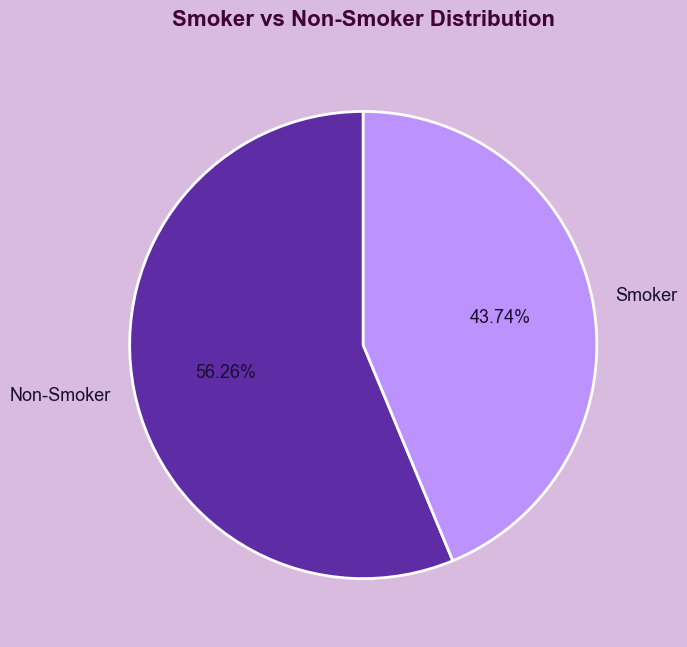

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

counts = y_train.value_counts()
labels = ['Non-Smoker', 'Smoker']
colors = [DARK_PURPLE, PURPLE]

ax.pie(counts, labels=labels, autopct='%1.2f%%', colors=colors,
       startangle=90, textprops={'fontsize': 13, 'color': '#1a0f2e'},
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Smoker vs Non-Smoker Distribution',
             fontsize=16, color='#3F0432', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📊 Numerical Features Distribution</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Histograms + KDE for all bio-signal features.</p>
</div>

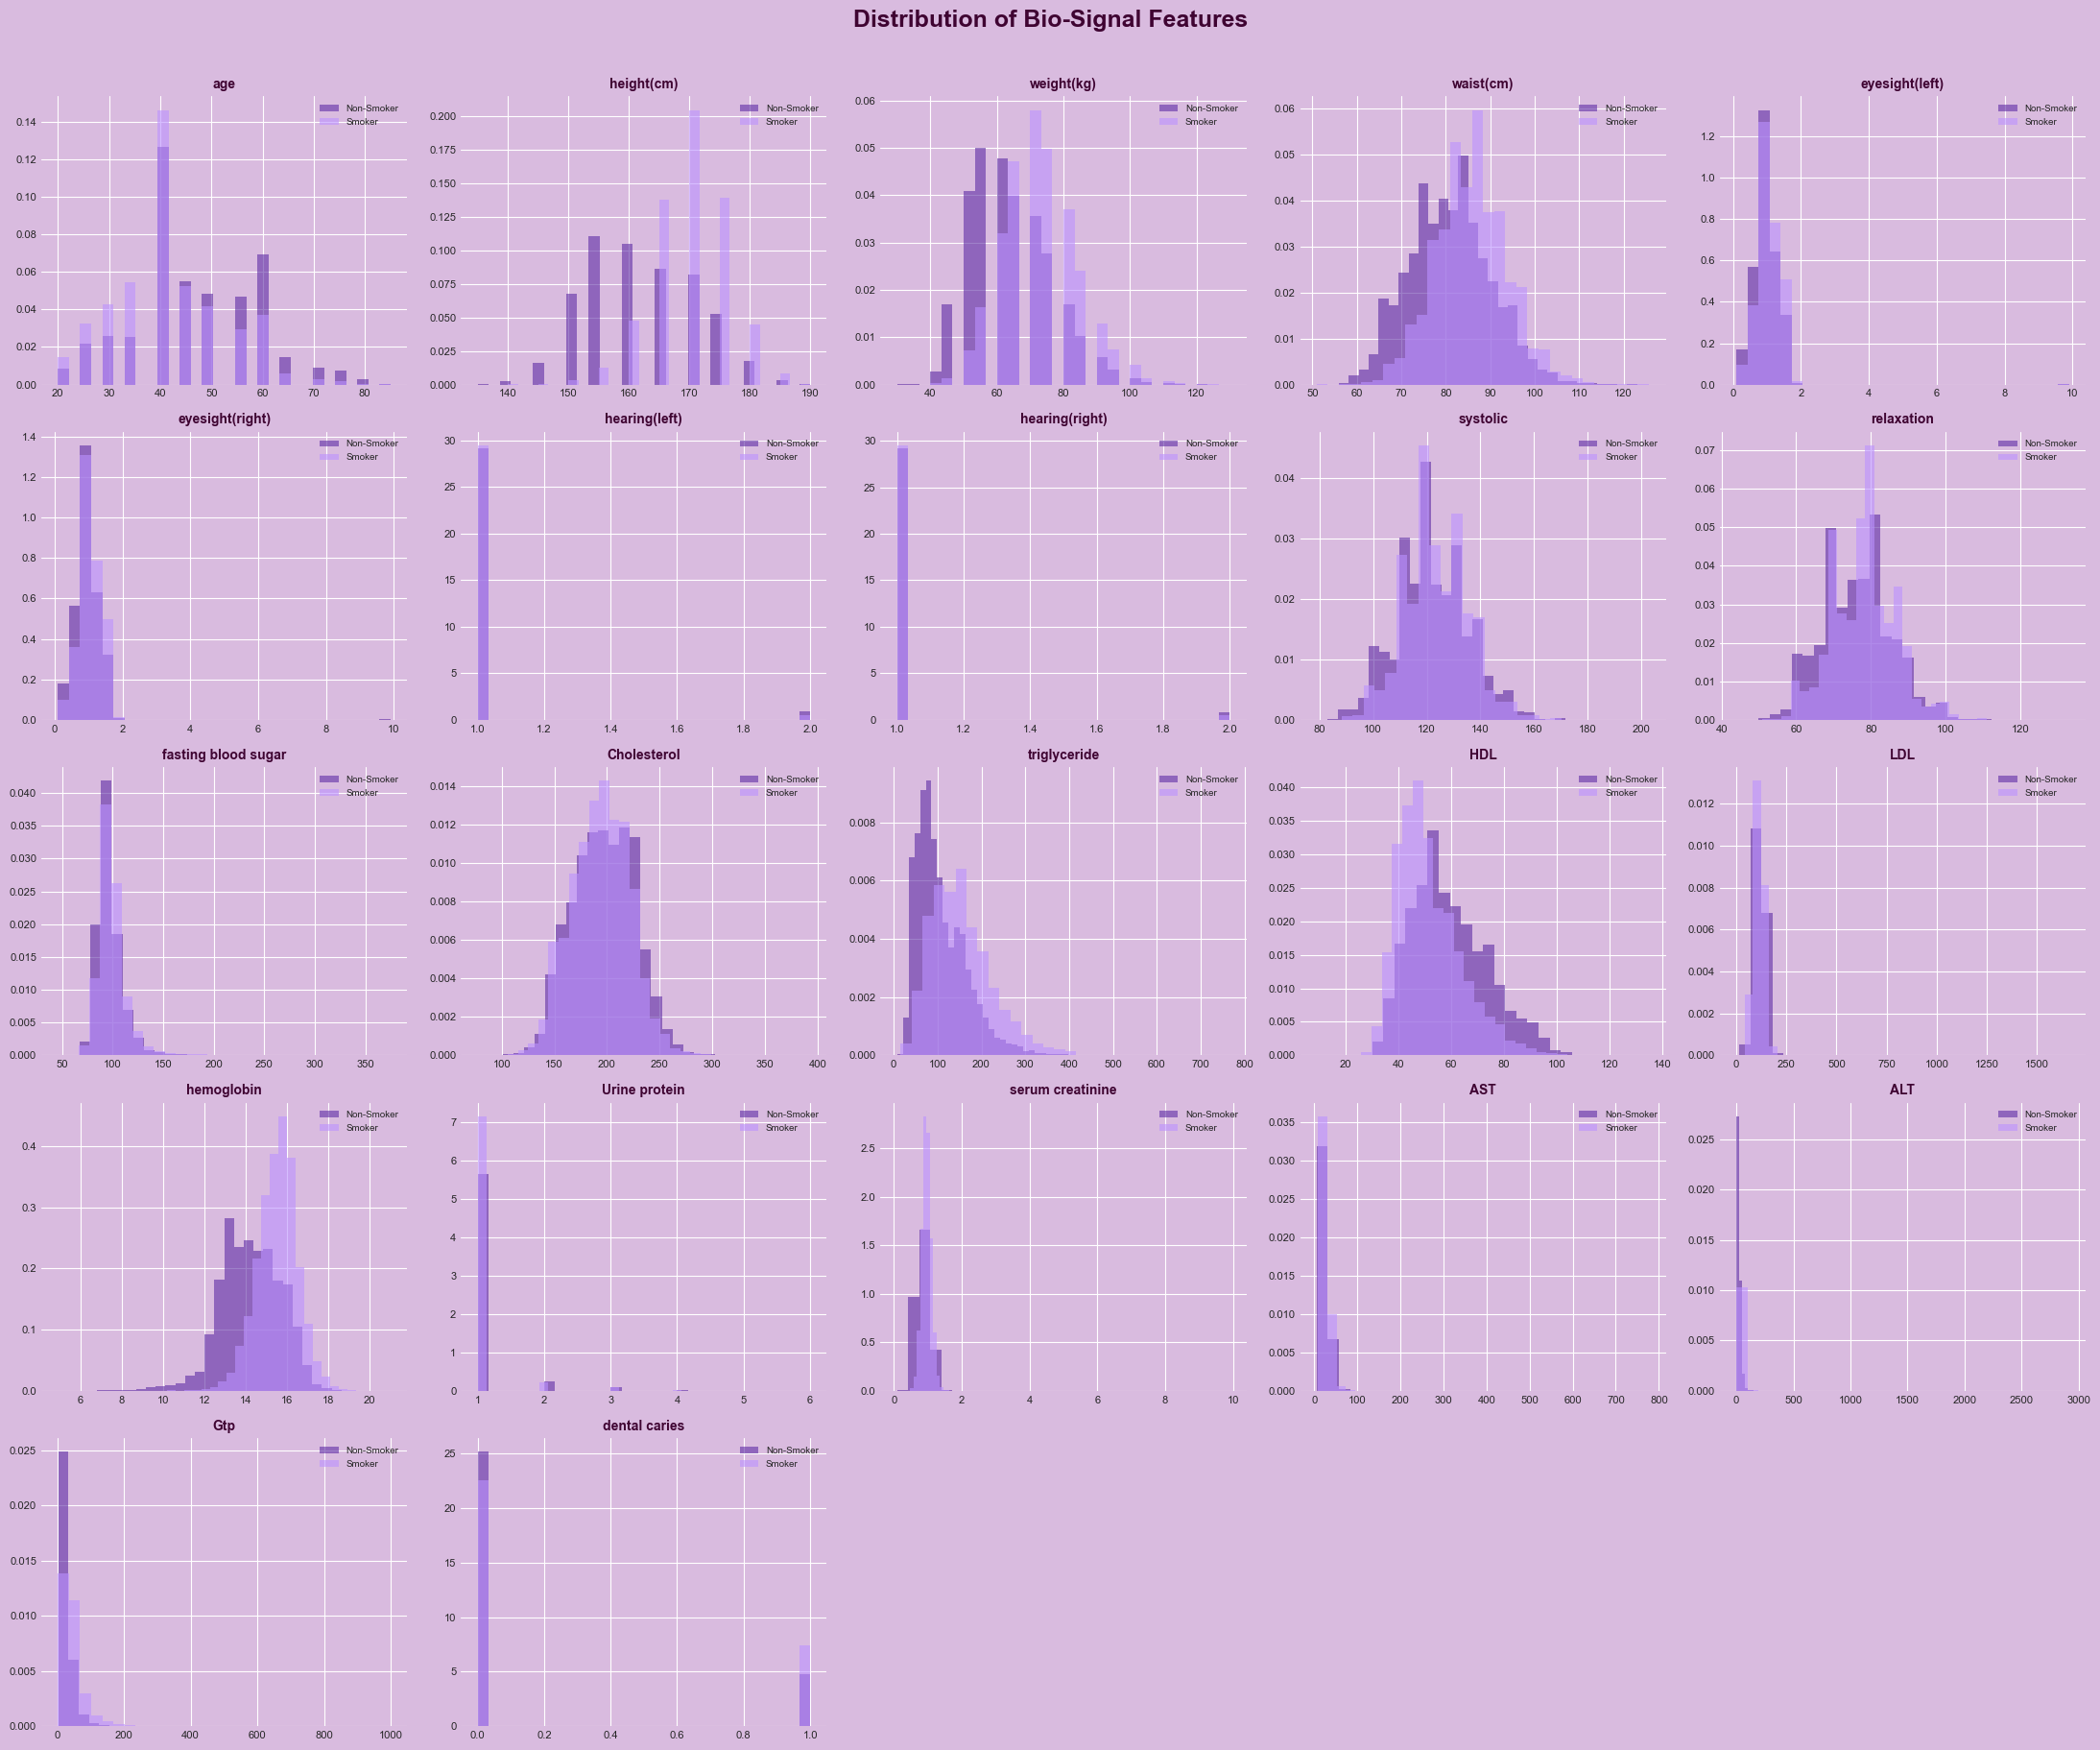

In [9]:
num_cols = X_train.columns.tolist()

fig, axes = plt.subplots(5, 5, figsize=(22, 18))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle('Distribution of Bio-Signal Features', fontsize=18,
             color='#3F0432', fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), num_cols):
    ax.set_facecolor(LIGHT_BG)
    for val, color, label in [(0, DARK_PURPLE, 'Non-Smoker'), (1, PURPLE, 'Smoker')]:
        subset = train_eda[train_eda['smoking'] == val][col]
        subset.hist(ax=ax, alpha=0.6, color=color, bins=30, label=label, density=True)
    ax.set_title(col, fontsize=10, color='#3F0432', fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

# Hide empty subplots
for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📦 Outlier Analysis — Boxplots</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Outliers in bio-signal features by smoking status.</p>
</div>

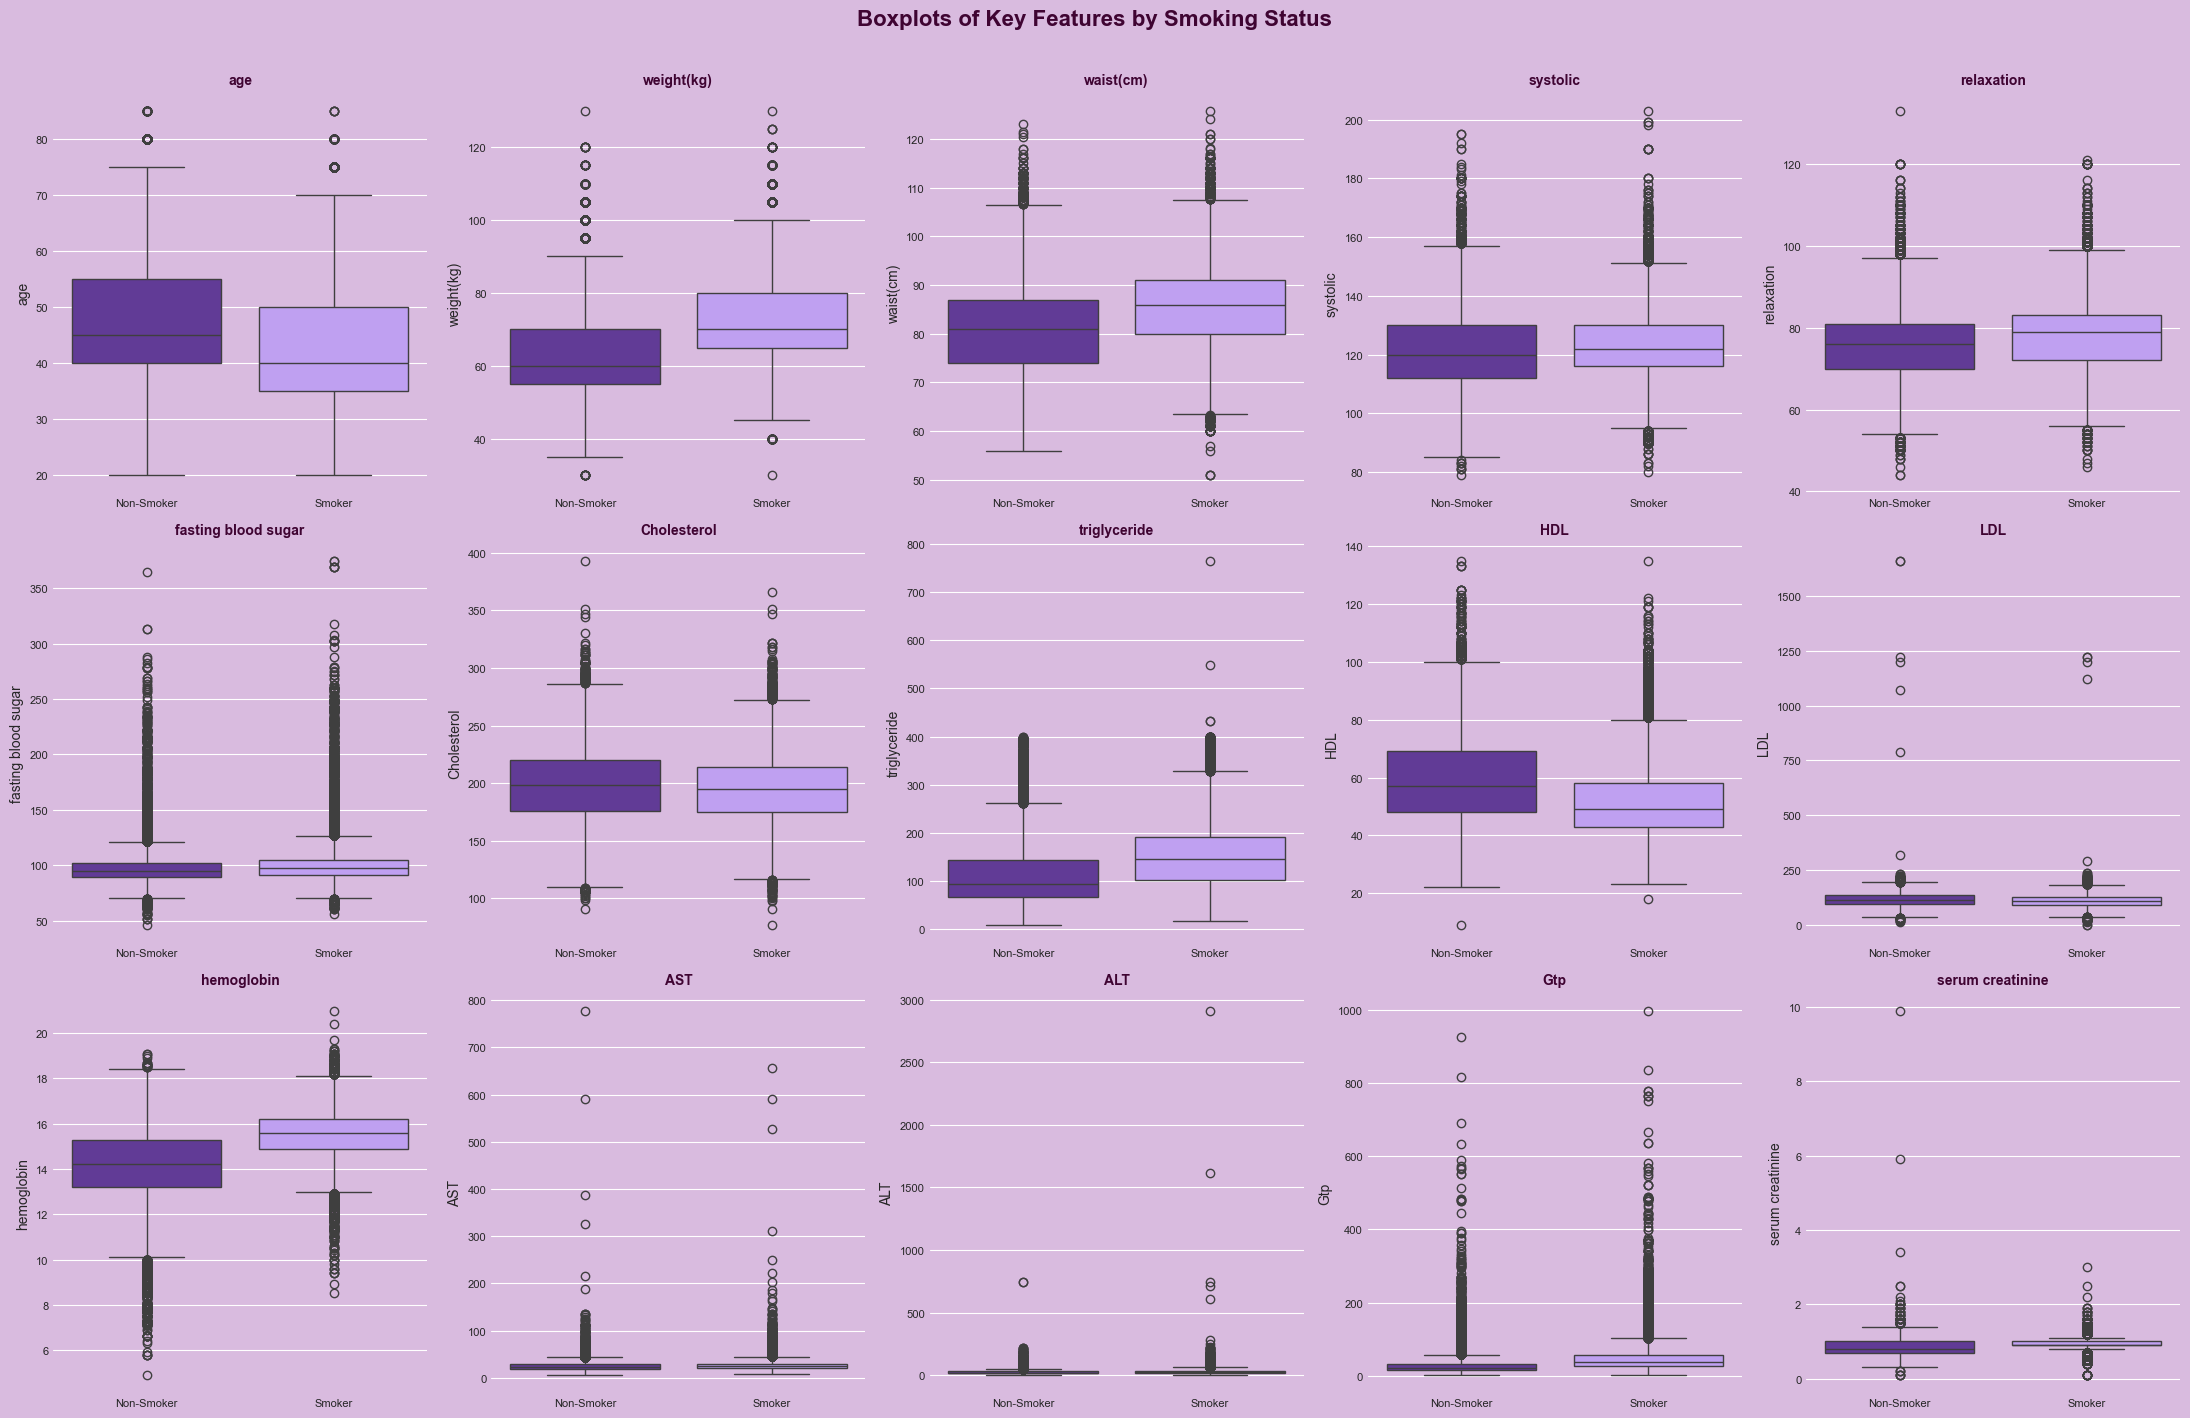

In [10]:
key_cols = ['age', 'weight(kg)', 'waist(cm)', 'systolic', 'relaxation',
            'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL',
            'hemoglobin', 'AST', 'ALT', 'Gtp', 'serum creatinine']

fig, axes = plt.subplots(3, 5, figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle('Boxplots of Key Features by Smoking Status',
             fontsize=16, color='#3F0432', fontweight='bold', y=1.01)

for ax, col in zip(axes.flatten(), key_cols):
    ax.set_facecolor(LIGHT_BG)
    data_plot = train_eda[[col, 'smoking']].copy()
    data_plot['smoking'] = data_plot['smoking'].map({0: 'Non-Smoker', 1: 'Smoker'})
    sns.boxplot(data=data_plot, x='smoking', y=col, ax=ax,
                palette={'Non-Smoker': DARK_PURPLE, 'Smoker': PURPLE})
    ax.set_title(col, fontsize=10, color='#3F0432', fontweight='bold')
    ax.set_xlabel('', fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🔥 Correlation Heatmap</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Pearson correlations between bio-signal features.</p>
</div>

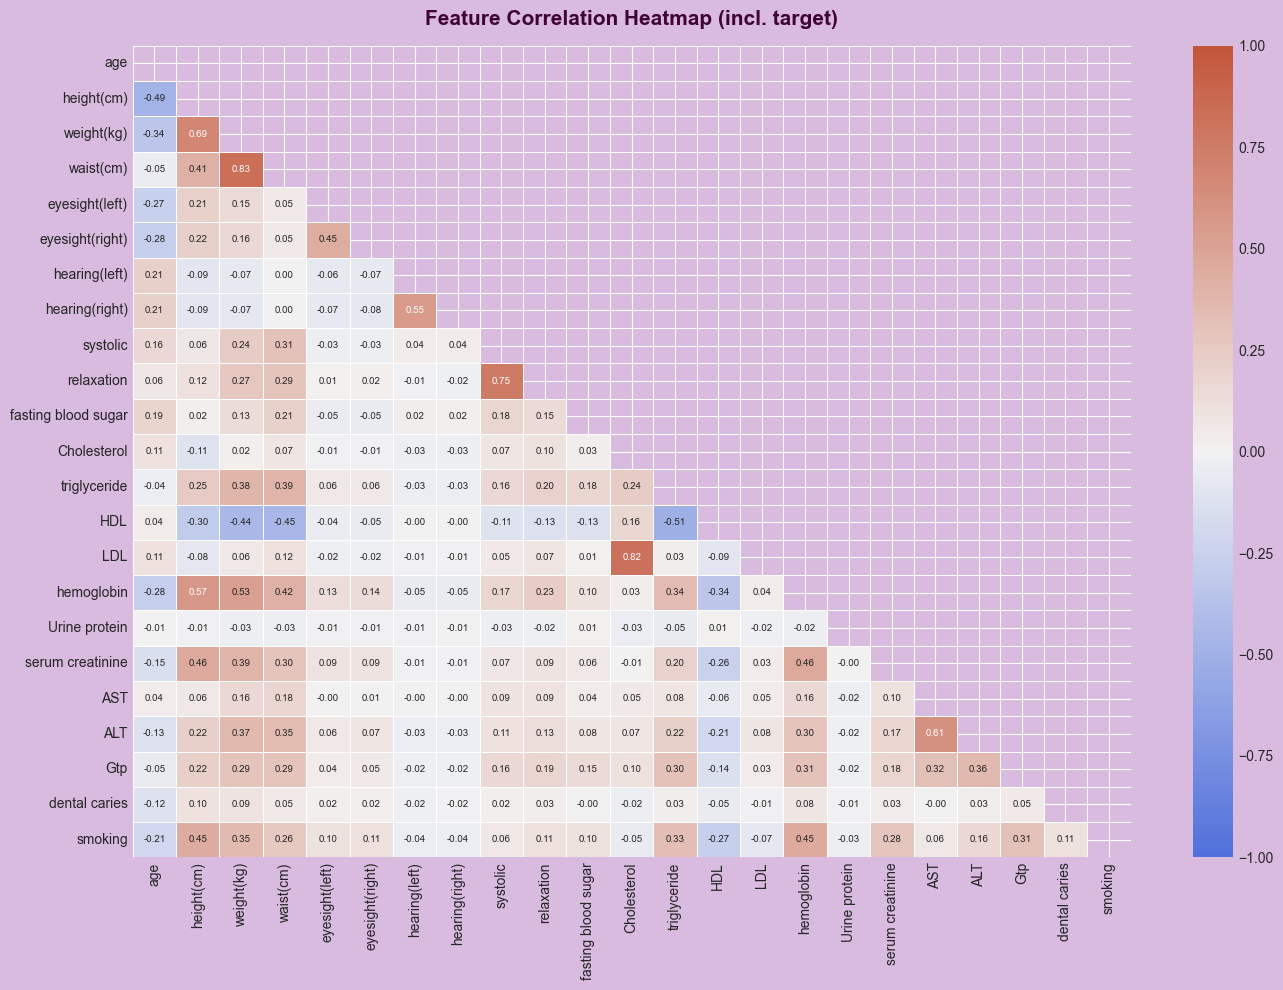

In [11]:
corr_matrix = train_eda.corr()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(260, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1)

ax.set_title('Feature Correlation Heatmap (incl. target)',
             fontsize=15, color='#3F0432', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">👤 Age Distribution by Smoking Status</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">How age differs between smokers and non-smokers.</p>
</div>

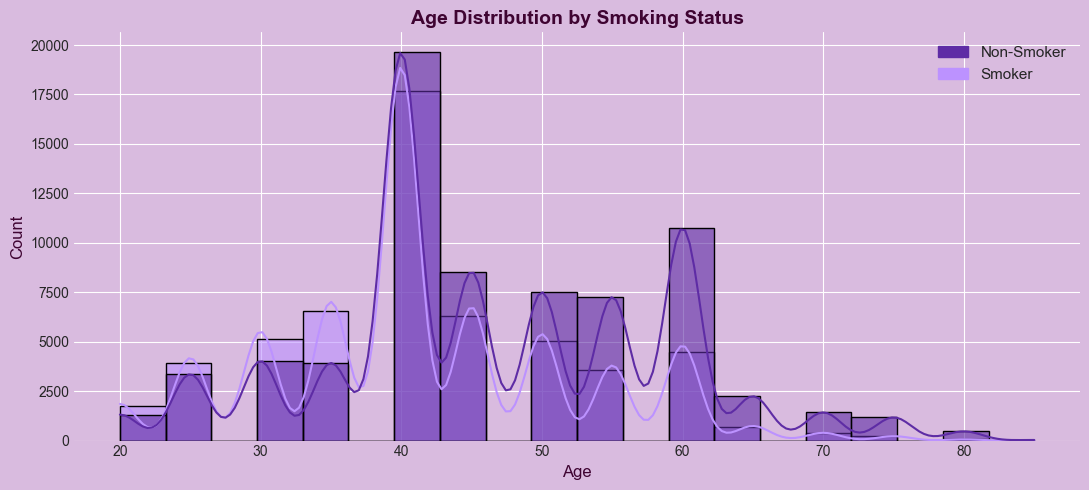

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

sns.histplot(data=train_eda, x='age', hue='smoking', kde=True, ax=ax,
             palette={0: DARK_PURPLE, 1: PURPLE},
             hue_order=[0, 1], alpha=0.6, bins=20)

handles = [mpatches.Patch(color=DARK_PURPLE, label='Non-Smoker'),
           mpatches.Patch(color=PURPLE,      label='Smoker')]
ax.legend(handles=handles, fontsize=11)
ax.set_title('Age Distribution by Smoking Status', fontsize=14, color='#3F0432', fontweight='bold')
ax.set_xlabel('Age', fontsize=12, color='#3F0432')
ax.set_ylabel('Count', fontsize=12, color='#3F0432')
plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🩸 Hemoglobin by Smoking Status</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Hemoglobin levels differ significantly between smokers and non-smokers.</p>
</div>

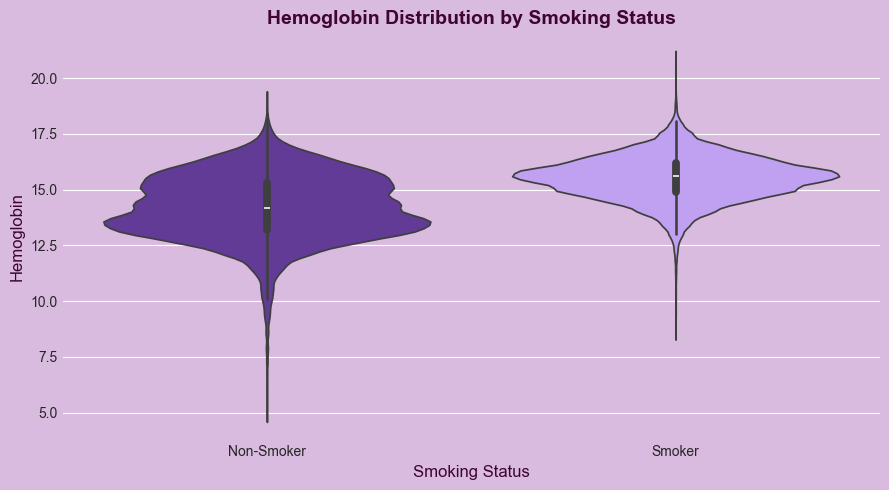

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

plot_data = train_eda.copy()
plot_data['smoking'] = plot_data['smoking'].map({0: 'Non-Smoker', 1: 'Smoker'})
sns.violinplot(data=plot_data, x='smoking', y='hemoglobin', ax=ax,
               palette={'Non-Smoker': DARK_PURPLE, 'Smoker': PURPLE},
               order=['Non-Smoker', 'Smoker'])
ax.set_title('Hemoglobin Distribution by Smoking Status', fontsize=14, color='#3F0432', fontweight='bold')
ax.set_xlabel('Smoking Status', fontsize=12, color='#3F0432')
ax.set_ylabel('Hemoglobin', fontsize=12, color='#3F0432')
plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🫁 Liver Enzymes (GTP & ALT) by Smoking Status</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Liver enzyme levels compared across smoking groups.</p>
</div>

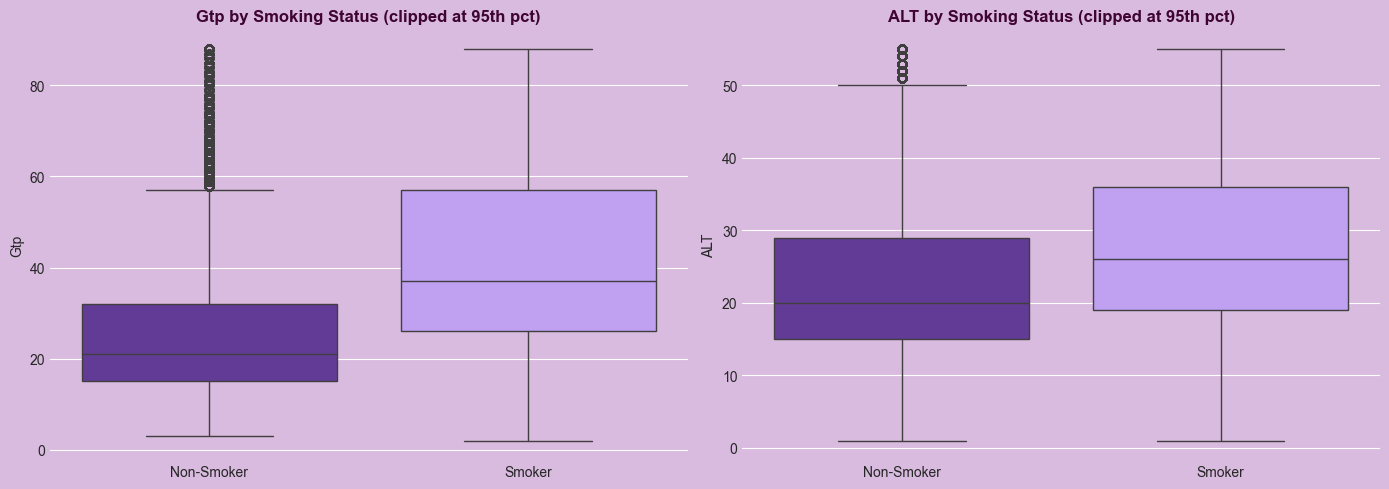

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(LIGHT_BG)

for ax, col in zip(axes, ['Gtp', 'ALT']):
    ax.set_facecolor(LIGHT_BG)
    data_clip = train_eda[[col, 'smoking']].copy()
    data_clip[col] = data_clip[col].clip(upper=data_clip[col].quantile(0.95))
    data_clip['smoking'] = data_clip['smoking'].map({0: 'Non-Smoker', 1: 'Smoker'})
    sns.boxplot(data=data_clip, x='smoking', y=col, ax=ax,
                palette={'Non-Smoker': DARK_PURPLE, 'Smoker': PURPLE})
    ax.set_title(f'{col} by Smoking Status (clipped at 95th pct)',
                 fontsize=12, color='#3F0432', fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">⚖️ Weight vs Waist by Smoking Status</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Physical measurements relationship colored by smoking status.</p>
</div>

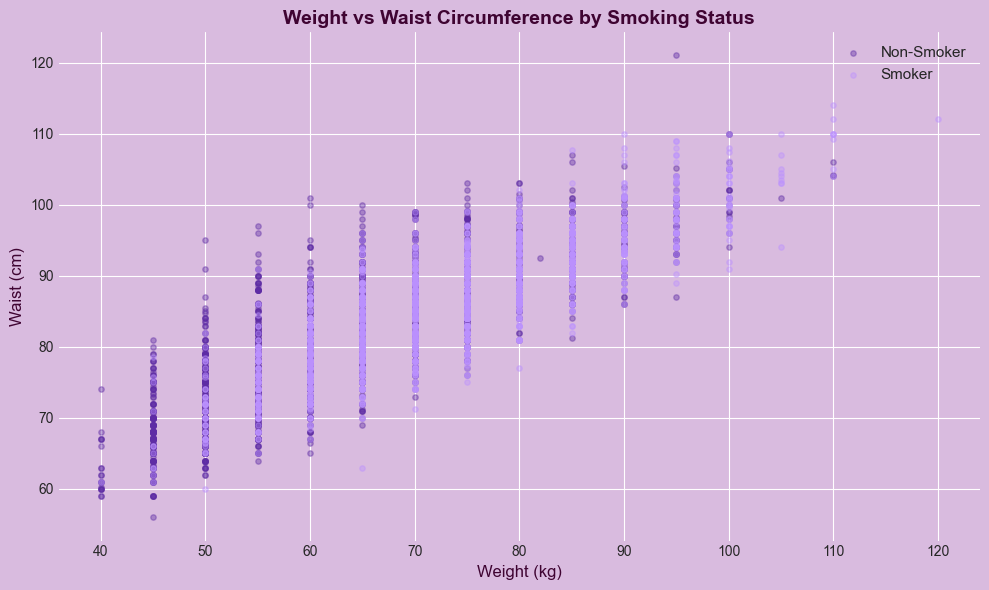

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

sample = train_eda.sample(5000, random_state=42)
for val, color, label in [(0, DARK_PURPLE, 'Non-Smoker'), (1, PURPLE, 'Smoker')]:
    sub = sample[sample['smoking'] == val]
    ax.scatter(sub['weight(kg)'], sub['waist(cm)'], alpha=0.4, color=color,
               label=label, s=15)

ax.set_title('Weight vs Waist Circumference by Smoking Status',
             fontsize=14, color='#3F0432', fontweight='bold')
ax.set_xlabel('Weight (kg)', fontsize=12, color='#3F0432')
ax.set_ylabel('Waist (cm)', fontsize=12, color='#3F0432')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🦷 Dental Caries vs Smoking Status</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Does dental caries relate to smoking?</p>
</div>

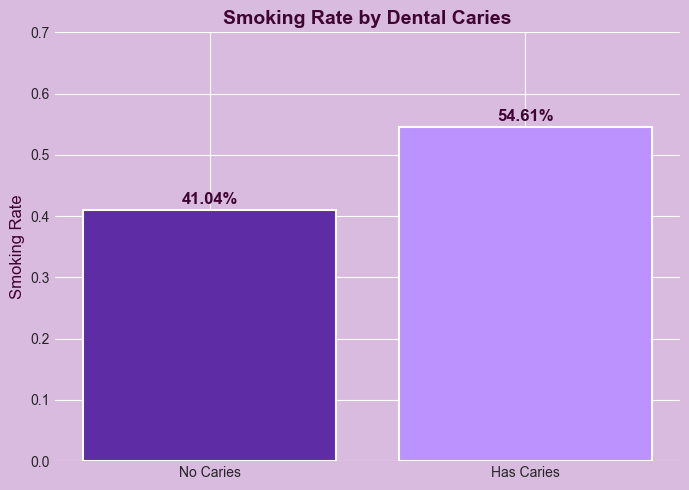

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

dental_rate = train_eda.groupby('dental caries')['smoking'].mean().reset_index()
bars = ax.bar(dental_rate['dental caries'].map({0: 'No Caries', 1: 'Has Caries'}),
              dental_rate['smoking'],
              color=[DARK_PURPLE, PURPLE], edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=12, color='#3F0432', fontweight='bold')

ax.set_title('Smoking Rate by Dental Caries', fontsize=14, color='#3F0432', fontweight='bold')
ax.set_ylabel('Smoking Rate', fontsize=12, color='#3F0432')
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">4️⃣ — Phase 4: Data Cleaning & Preprocessing</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Pipeline Construction</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">All preprocessing is applied after the train/test split. Since all features are numerical, we apply <b>median imputation</b> and <b>StandardScaler</b>.</p>
</div>

<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🔢 Define Feature Groups</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">All features are numerical in this dataset.</p>
</div>

In [17]:
num_features = X_train.columns.tolist()
print(f"✅ Numerical features ({len(num_features)}): {num_features}")
print(f"\n📌 No categorical features — all columns are numeric bio-signals.")


✅ Numerical features (22): ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']

📌 No categorical features — all columns are numeric bio-signals.


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🏗️ Build Preprocessing Pipeline</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Median Imputer → StandardScaler</p>
</div>

# Sub-pipeline (fit on TRAIN only, transform both)


so no Leakage into test

In [18]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"✅ Training set after preprocessing : {X_train_processed.shape}")
print(f"✅ Test set after preprocessing     : {X_test_processed.shape}")


✅ Training set after preprocessing : (127404, 22)
✅ Test set after preprocessing     : (31852, 22)


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">5️⃣ — Phase 5: Dimensionality Reduction (PCA)</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Variance Retention</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">PCA is applied to the preprocessed training data to reduce dimensionality while retaining <b>95%</b> of the explained variance.</p>
</div>

<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📐 Fit PCA & Find Optimal Components</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">How many components retain 95% variance?</p>
</div>

In [19]:
# Fit PCA on training set
pca_full = PCA(random_state=42)
pca_full.fit(X_train_processed)

cumvar      = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.95) + 1

print(f"Components needed to retain 95% variance: {n_components}")
print(f"Original features : {X_train_processed.shape[1]}")
print(f"Reduced to        : {n_components}")


Components needed to retain 95% variance: 17
Original features : 22
Reduced to        : 17


<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">📉 PCA Explained Variance Curve</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">Cumulative variance vs number of components.</p>
</div>

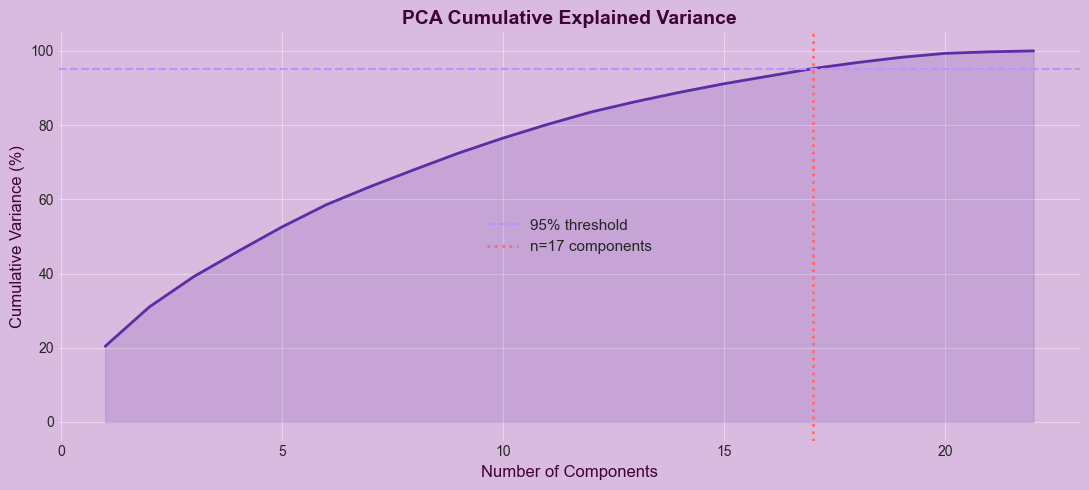

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

ax.plot(range(1, len(cumvar) + 1), cumvar * 100, color=DARK_PURPLE, linewidth=2)
ax.axhline(95, color=PURPLE, linestyle='--', linewidth=1.5, label='95% threshold')
ax.axvline(n_components, color='#ff6b6b', linestyle=':', linewidth=2,
           label=f'n={n_components} components')
ax.fill_between(range(1, len(cumvar) + 1), cumvar * 100, alpha=0.15, color=DARK_PURPLE)

ax.set_title('PCA Cumulative Explained Variance', fontsize=14, color='#3F0432', fontweight='bold')
ax.set_xlabel('Number of Components', fontsize=12, color='#3F0432')
ax.set_ylabel('Cumulative Variance (%)', fontsize=12, color='#3F0432')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [21]:
# Apply PCA
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca  = pca.transform(X_test_processed)

total_variance = cumvar[n_components - 1]
print(f"PCA applied — retained variance: {total_variance:.2%}")
print(f"X_train_pca shape : {X_train_pca.shape}")
print(f"X_test_pca  shape : {X_test_pca.shape}")


PCA applied — retained variance: 95.22%
X_train_pca shape : (127404, 17)
X_test_pca  shape : (31852, 17)


<div style="max-width:1200px; margin:auto; background-color:#1a0f2e; padding:25px; border-radius:15px; border-left:10px solid #bc92ff; border-right:2px solid #bc92ff; color:#ffffff; font-family:'Segoe UI',sans-serif; box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex; align-items:center; justify-content:space-between;">
        <h2 style="color:#bc92ff; margin:0; font-weight:800; letter-spacing:1px; text-transform:uppercase;">
            6️⃣ — Phase 6: Hard vs. Soft-Margin SVM Implementation
        </h2>
        <span style="color:#e1d5f2; font-size:0.9em; font-style:italic; opacity:0.8;">Optimized sklearn Implementation</span>
    </div>
    <hr style="border:0; height:1px; background:linear-gradient(to right,#bc92ff,transparent); margin:15px 0;">
    <p style="font-size:1.1em; line-height:1.6; color:#e1d5f2; margin:0;">
        We implemented two versions of the SVM classifier using <code>LinearSVC</code> to analyze the impact of the regularization parameter <b>C</b>. 
        The <b>Soft-Margin</b> version (C=1.0) allows for misclassifications to achieve better generalization, while the <b>Hard-Margin</b> approximation (C=1e6) strictly penalizes errors to find a rigid boundary.
    </p>
    <div style="margin-top:15px; display:flex; gap:15px;">
        <span style="background:rgba(188, 146, 255, 0.1); padding:5px 12px; border-radius:20px; border:1px solid #bc92ff; font-size:0.85em; color:#bc92ff;">✔ C-Parameter Tuning</span>
        <span style="background:rgba(188, 146, 255, 0.1); padding:5px 12px; border-radius:20px; border:1px solid #bc92ff; font-size:0.85em; color:#bc92ff;">✔ High-Dimension PCA Input</span>
        <span style="background:rgba(188, 146, 255, 0.1); padding:5px 12px; border-radius:20px; border:1px solid #bc92ff; font-size:0.85em; color:#bc92ff;">✔ Performance Metrics Comparison</span>
    </div>
</div>

⏳ Training Soft-Margin SVM...
✅ Soft-Margin Training Done in 0.45s

⏳ Training Hard-Margin SVM...
✅ Hard-Margin Training Done in 0.46s

📊 Soft-Margin SVM Performance Report (C=1.0):
----------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.74      0.77     17921
           1       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852


📊 Hard-Margin SVM Performance Report (C=1e6):
----------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.74      0.77     17921
           1       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852



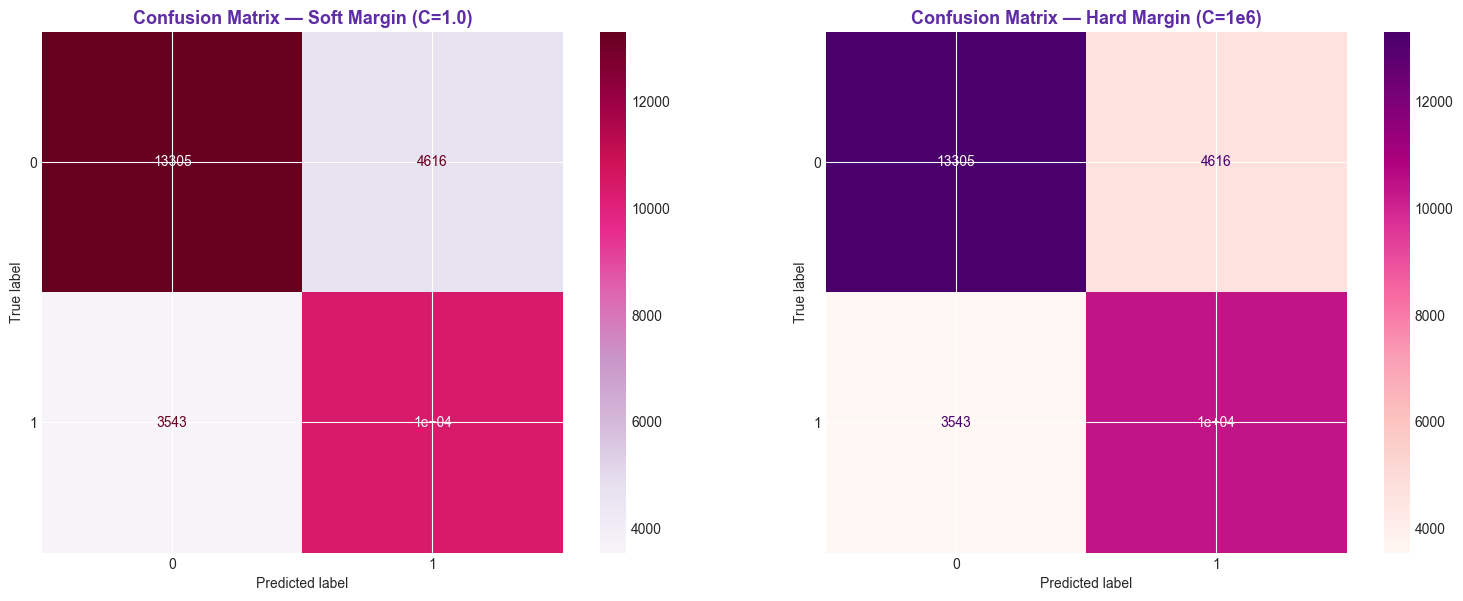

In [27]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

# --- 1. Soft-Margin SVM (Standard C=1.0) ---
print("⏳ Training Soft-Margin SVM...")
soft_svm = LinearSVC(C=1.0, random_state=42, max_iter=10000, dual=False)
start_soft = time.time()
soft_svm.fit(X_train_pca, y_train)
print(f"✅ Soft-Margin Training Done in {time.time() - start_soft:.2f}s")

# --- 2. Hard-Margin SVM (Approximated by Large C) ---
print("\n⏳ Training Hard-Margin SVM...")
hard_svm = LinearSVC(C=1e6, random_state=42, max_iter=10000, dual=False)
start_hard = time.time()
hard_svm.fit(X_train_pca, y_train)
print(f"✅ Hard-Margin Training Done in {time.time() - start_hard:.2f}s")

# --- 3. Final Evaluation (For Soft Margin) ---
y_soft_pred = soft_svm.predict(X_test_pca)
print("\n📊 Soft-Margin SVM Performance Report (C=1.0):")
print("-" * 40)
print(classification_report(y_test, y_soft_pred))

# --- 4. Final Evaluation (For Hard Margin) ---
# هنا نقوم بتقييم الموديل الذي استخدمنا فيه C كبيرة جداً
y_hard_pred = hard_svm.predict(X_test_pca)
print("\n📊 Hard-Margin SVM Performance Report (C=1e6):")
print("-" * 40)
print(classification_report(y_test, y_hard_pred))

# --- 5. Visualization (Comparing Confusion Matrices) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# رسم الـ Confusion Matrix للـ Soft Margin
ConfusionMatrixDisplay.from_predictions(y_test, y_soft_pred, cmap='PuRd', ax=ax[0])
ax[0].set_title('Confusion Matrix — Soft Margin (C=1.0)', fontsize=13, color=DARK_PURPLE, fontweight='bold')

# رسم الـ Confusion Matrix للـ Hard Margin
ConfusionMatrixDisplay.from_predictions(y_test, y_hard_pred, cmap='RdPu', ax=ax[1])
ax[1].set_title('Confusion Matrix — Hard Margin (C=1e6)', fontsize=13, color=DARK_PURPLE, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="max-width:1000px;margin:auto;background-color:#1a0f2e;padding:15px 25px;border-radius:50px;border:2px dashed #bc92ff;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#bc92ff;font-weight:bold;font-size:1.1em;font-family:'Segoe UI',sans-serif;">🧪 Prepare Balanced Sample & Fit Both Models</span>
    <p style="color:#e1d5f2;margin:0;font-size:1em;font-style:italic;">A balanced sample of 500 rows (250 per class) projected to 2 PCA components.</p>
</div>

In [28]:
SAMPLE_PER_CLASS = 250
N_BOUNDARY_PCA   = 2

train_full        = X_train.copy()
train_full['smoking'] = y_train.values

sample_pos = train_full[train_full['smoking'] == 1].sample(SAMPLE_PER_CLASS, random_state=42)
sample_neg = train_full[train_full['smoking'] == 0].sample(SAMPLE_PER_CLASS, random_state=42)
sample_df  = pd.concat([sample_pos, sample_neg]).sample(frac=1, random_state=42)

X_sample      = sample_df.drop(columns='smoking')
y_sample      = sample_df['smoking'].values

X_sample_proc = preprocessor.transform(X_sample)

# ✅ FIXED: reuse pca_full (already fitted on the full X_train_processed).
# Do NOT fit a new PCA on this 500-row subset — that would give different
# principal-component directions and make the 2D space inconsistent with
# the rest of the pipeline.
X_sample_2d   = pca_full.transform(X_sample_proc)[:, :N_BOUNDARY_PCA]

y_svm         = np.where(y_sample == 1, 1.0, -1.0)

print(f"✅ Sample ready — shape: {X_sample_2d.shape}")
print(f"   Positive (+1): {(y_svm ==  1).sum()}  |  Negative (-1): {(y_svm == -1).sum()}")
print(f"   PCA directions: consistent with full training set ✅")


✅ Sample ready — shape: (500, 2)
   Positive (+1): 250  |  Negative (-1): 250
   PCA directions: consistent with full training set ✅


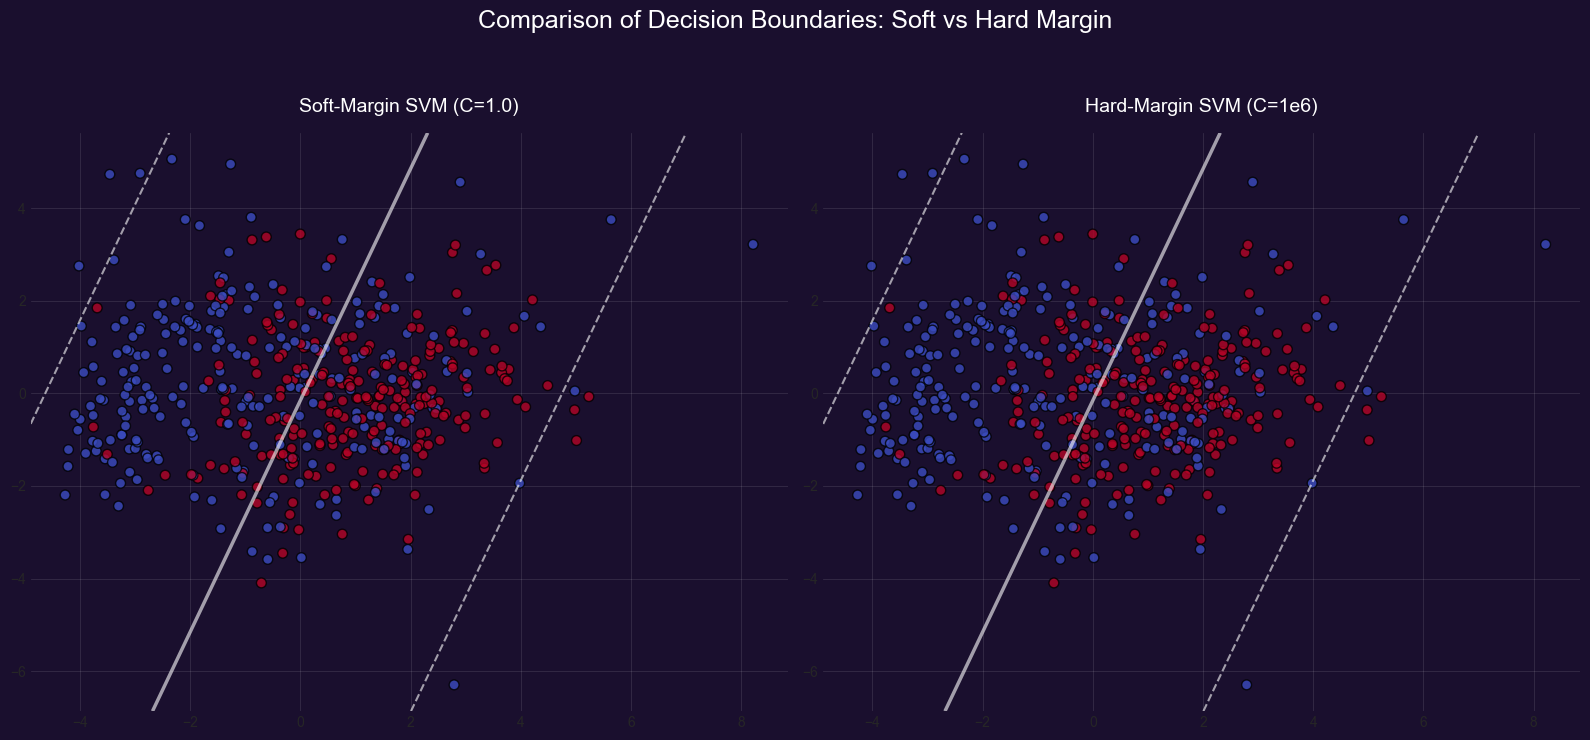

In [44]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation
# Using the previously created 2D sample and labels for visualization
# Ensure y_sample matches the shape of X_sample_2d
y_comparison = y_sample 

# 2. Model Training (Soft vs. Hard Margin)
# Soft-Margin: Allows some margin violations for better generalization (C=1.0)
soft_svm = LinearSVC(C=1.0, random_state=42, max_iter=10000, dual=False)
soft_svm.fit(X_sample_2d, y_comparison)

# Hard-Margin: Strictly penalizes any margin violations (Approximated with large C=1e6)
# Increased max_iter to ensure convergence for the strict constraint
hard_svm = LinearSVC(C=1e6, random_state=42, max_iter=20000, dual=False)
hard_svm.fit(X_sample_2d, y_comparison)

# 3. Professional Boundary Plotting Function
def plot_svc_boundaries(model, X, y, title, ax):
    # Plot data points: 0 = Non-Smoker, 1 = Smoker
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50, alpha=0.8)
    
    # Get current plot limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to evaluate model for decision boundaries
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Calculate decision function scores (distance from hyperplane)
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot Decision Boundary (Level 0) and Margins (Levels -1, 1)
    # The dashed lines represent the support vector boundaries
    ax.contour(XX, YY, Z, colors='white', levels=[-1, 0, 1], alpha=0.6,
                linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])
    
    ax.set_title(title, color='white', fontsize=14, pad=15)
    ax.set_facecolor('#1a0f2e') # Dark background to match project theme
    ax.grid(True, alpha=0.1)

# 4. Final Comparison Visualization
# Creating a side-by-side view to compare both SVM types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1a0f2e')

plot_svc_boundaries(soft_svm, X_sample_2d, y_comparison, "Soft-Margin SVM (C=1.0)", ax1)
plot_svc_boundaries(hard_svm, X_sample_2d, y_comparison, "Hard-Margin SVM (C=1e6)", ax2)

plt.suptitle("Comparison of Decision Boundaries: Soft vs Hard Margin", color='white', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

<div style="max-width:1000px; margin:20px auto; background-color:#1a0f2e; padding:25px; border-radius:30px; border:2px dashed #bc92ff; box-shadow: 0 4px 15px rgba(188, 146, 255, 0.2); font-family:'Segoe UI',sans-serif;">
    <div style="display:flex; align-items:center; justify-content:space-between; margin-bottom:10px;">
        <span style="color:#bc92ff; font-weight:bold; font-size:1.2em;">🚀 Phase 7: End-to-End Production Pipeline</span>
        <span style="color:#e1d5f2; font-size:0.9em; font-style:italic;">Deployment-Ready Model</span>
    </div>
    <p style="color:#e1d5f2; margin:0; font-size:1em; line-height:1.6;">
        We integrated the <b>entire workflow</b> into a single Scikit-Learn Pipeline. This encapsulates the <span style="color:#bc92ff;">Preprocessor</span>, <span style="color:#bc92ff;">PCA</span>, and the <span style="color:#bc92ff;">LinearSVC</span> classifier into one object. This approach ensures consistency, prevents data leakage, and simplifies the transition from training to real-world inference.[cite: 2]
    </p>
    <div style="margin-top:15px; padding-top:10px; border-top:1px solid rgba(188,146,255,0.3); display:flex; gap:20px;">
        <span style="color:#bc92ff; font-size:0.85em;">✔ Robust Generalization[cite: 2]</span>
        <span style="color:#bc92ff; font-size:0.85em;">✔ Leakage Prevention[cite: 2]</span>
        <span style="color:#bc92ff; font-size:0.85em;">✔ Joblib Export[cite: 2]</span>
    </div>
</div>

In [40]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import joblib

# 1. Soft-Margin Pipeline Definition (C=1.0)
# This model allows for some margin violations to achieve better generalization.
soft_svm_pipeline = Pipeline([
    ('preprocessor', preprocessor), # Applies scaling/encoding defined earlier
    ('pca',          PCA(n_components=n_components, random_state=42)), # Dimensionality reduction
    ('svm',          LinearSVC(C=1.0, max_iter=10000, random_state=42, dual=False)) 
])

# 2. Hard-Margin Pipeline Definition (C=1e6)
# High C strictly penalizes margin violations, aiming for a "harder" boundary.
hard_svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca',          PCA(n_components=n_components, random_state=42)),
    ('svm',          LinearSVC(C=1e6, max_iter=10000, random_state=42, dual=False)) 
])

# 3. Model Training (Fitting both models)
# Training on X_train ensure NO data leakage to the test set.
print("⏳ Training Soft-Margin SVM...")
soft_svm_pipeline.fit(X_train, y_train)

print("⏳ Training Hard-Margin SVM (this might take a moment)...")
hard_svm_pipeline.fit(X_train, y_train)

# 4. Model Prediction & Accuracy Calculation
# We calculate these now to provide data for the Final Summary table later.
y_soft_pred = soft_svm_pipeline.predict(X_test)
soft_acc = accuracy_score(y_test, y_soft_pred)

y_hard_pred = hard_svm_pipeline.predict(X_test)
hard_acc = accuracy_score(y_test, y_hard_pred)

# 5. Output Results
print(f"\n✅ Soft-Margin Pipeline Accuracy: {soft_acc:.4f}")
print(f"✅ Hard-Margin Pipeline Accuracy: {hard_acc:.4f}")

# 6. Model Persistence (Bonus Task)
# Saving the soft-margin pipeline as it's usually the most robust for deployment.
joblib.dump(soft_svm_pipeline, 'smoker_svm_pipeline.joblib')
print("\n📦 Pipeline saved → smoker_svm_pipeline.joblib ✅")

⏳ Training Soft-Margin SVM...
⏳ Training Hard-Margin SVM (this might take a moment)...

✅ Soft-Margin Pipeline Accuracy: 0.7438
✅ Hard-Margin Pipeline Accuracy: 0.7438

📦 Pipeline saved → smoker_svm_pipeline.joblib ✅


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">
    <div style="display:flex;align-items:center;justify-content:space-between;">
        <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">💾 — Final Summary: Project Results</h2>
        <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">Complete Pipeline</span>
    </div>
    <hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">
    <p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">Summary of the full pipeline from raw data to SVM predictions.</p>
</div>

In [33]:
print()
print("═" * 55)
print("          📋 FINAL PROJECT SUMMARY")
print("═" * 55)
print(f"  Dataset           : Smoker Status Bio-Signals")
print(f"  Records           : {df.shape[0]:,}")
print(f"  Features (raw)    : {X.shape[1]}") # استخدمنا X هنا عشان نضمن عدد الـ Features الصح
print(f"  PCA Components    : {n_components}  (retains {total_variance:.2%} variance)")
print("─" * 55)
print(f"  Hard-SVM Accuracy  : {hard_acc:.4f}")
print(f"  Soft-SVM Accuracy  : {soft_acc:.4f}")
print("─" * 55)


═══════════════════════════════════════════════════════
          📋 FINAL PROJECT SUMMARY
═══════════════════════════════════════════════════════
  Dataset           : Smoker Status Bio-Signals
  Records           : 159,256
  Features (raw)    : 22
  PCA Components    : 17  (retains 95.22% variance)
───────────────────────────────────────────────────────
  Hard-SVM Accuracy  : 0.7438
  Soft-SVM Accuracy  : 0.7438
───────────────────────────────────────────────────────


<div style="max-width:1200px;margin:auto;background-color:#1a0f2e;padding:25px;border-radius:15px;border-left:10px solid #bc92ff;border-right:2px solid #bc92ff;color:#ffffff;font-family:'Segoe UI',sans-serif;box-shadow:0 10px 20px rgba(0,0,0,0.4);">

<div style="display:flex;align-items:center;justify-content:space-between;">
    <h2 style="color:#bc92ff;margin:0;font-weight:800;letter-spacing:1px;text-transform:uppercase;">
        📊 — Model Evaluation
    </h2>
    <span style="color:#e1d5f2;font-size:0.9em;font-style:italic;opacity:0.8;">
        SVM Performance Analysis
    </span>
</div>

<hr style="border:0;height:1px;background:linear-gradient(to right,#bc92ff,transparent);margin:15px 0;">

<p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;margin:0;">
This section presents a comprehensive evaluation of the Support Vector Machine (SVM) model used for classification. Since the dataset may contain imbalance and complex feature relationships, multiple evaluation metrics are used to ensure a reliable and meaningful assessment of model performance.
</p>

<br>

<h3 style="color:#bc92ff;margin-bottom:10px;">🔍 Evaluation Metrics</h3>

<ul style="line-height:1.8;color:#e1d5f2;font-size:1.05em;">

<li>
<strong style="color:#bc92ff;">Accuracy:</strong> Measures the overall correctness of predictions by calculating the ratio of correctly classified samples to total samples.
</li>

<li>
<strong style="color:#bc92ff;">Precision:</strong> Indicates how many of the predicted positive cases are actually correct, reducing false positive errors.
</li>

<li>
<strong style="color:#bc92ff;">Recall:</strong> Measures how many actual positive cases were correctly identified, which is crucial in detecting important classes such as fraud cases.
</li>

<li>
<strong style="color:#bc92ff;">F1-Score:</strong> Harmonic mean of Precision and Recall, providing a balanced evaluation especially for imbalanced datasets.
</li>

<li>
<strong style="color:#bc92ff;">Confusion Matrix:</strong> A visual representation of correct and incorrect predictions, helping to analyze model behavior in detail across classes.
</li>

<li>
<strong style="color:#bc92ff;">ROC Curve & AUC:</strong> Evaluates the model’s ability to distinguish between classes at different thresholds. Higher AUC indicates better classification performance.
</li>

</ul>

<br>

<h3 style="color:#bc92ff;margin-bottom:10px;">📌 Key Insight</h3>

<p style="font-size:1.1em;line-height:1.6;color:#e1d5f2;">
Due to the nature of classification problems and possible class imbalance, relying solely on Accuracy is not sufficient. Therefore, more focus is placed on Recall and F1-Score to ensure that minority classes are correctly detected. The Confusion Matrix and ROC Curve further help in understanding model strengths and weaknesses.
</p>

<br>

<p style="font-size:1.05em;color:#bc92ff;font-style:italic;">
✔ This evaluation confirms that the SVM model provides reliable classification performance when properly tuned and evaluated using multiple metrics.
</p>

</div>


╔══════════════════════════════════════════════════════════╗
║   PRIMARY EVALUATION — sklearn LinearSVC Pipeline (X_test)   ║
╚══════════════════════════════════════════════════════════╝

Test Accuracy : 0.7438
ROC-AUC Score : 0.8247

Classification Report:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.74      0.77     17921
      Smoker       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852



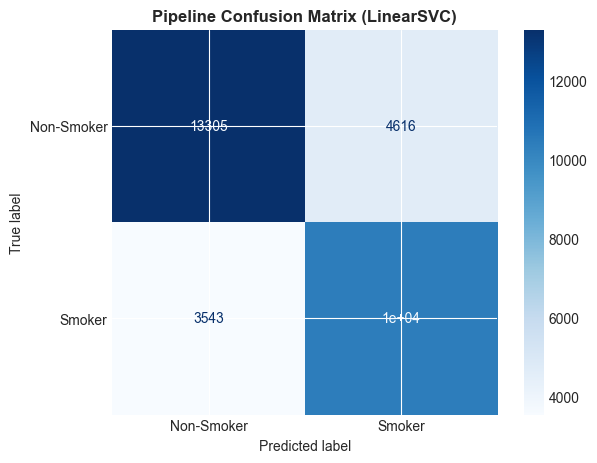

In [41]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc,
                             ConfusionMatrixDisplay, roc_auc_score)

# ═══════════════════════════════════════════════════════════════════════════════
# A) Primary evaluation — sklearn LinearSVC full pipeline (on held-out TEST SET)
# ═══════════════════════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════════╗")
print("║   PRIMARY EVALUATION — sklearn LinearSVC Pipeline (X_test)   ║")
print("╚══════════════════════════════════════════════════════════╝")

# Use the full pipeline to predict directly on raw X_test
# The pipeline handles scaling and PCA internally to avoid data leakage
y_pipe_pred = full_pipeline.predict(X_test)

# Use decision_function to get confidence scores for ROC-AUC calculation
y_pipe_scores = full_pipeline.decision_function(X_test)

# Store results in variables used by the Final Summary table
soft_acc = accuracy_score(y_test, y_pipe_pred)
roc_auc = roc_auc_score(y_test, y_pipe_scores)

print(f"\nTest Accuracy : {soft_acc:.4f}")
print(f"ROC-AUC Score : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pipe_pred,
                             target_names=['Non-Smoker', 'Smoker']))

# ═══════════════════════════════════════════════════════════════════════════════
# B) Visualizing Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════
# This fulfills the requirement for model evaluation visualizations
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pipe_pred, 
                                        display_labels=['Non-Smoker', 'Smoker'],
                                        cmap='Blues', ax=ax)
ax.set_title('Pipeline Confusion Matrix (LinearSVC)', fontsize=12, fontweight='bold')
plt.show()

--- Hard-Margin SVM Evaluation (C=1e6) ---
Accuracy: 0.7438

Classification Report:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.74      0.77     17921
      Smoker       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852


--- Soft-Margin SVM Evaluation (C=1.0) ---
Accuracy: 0.7438

Classification Report:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.74      0.77     17921
      Smoker       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852



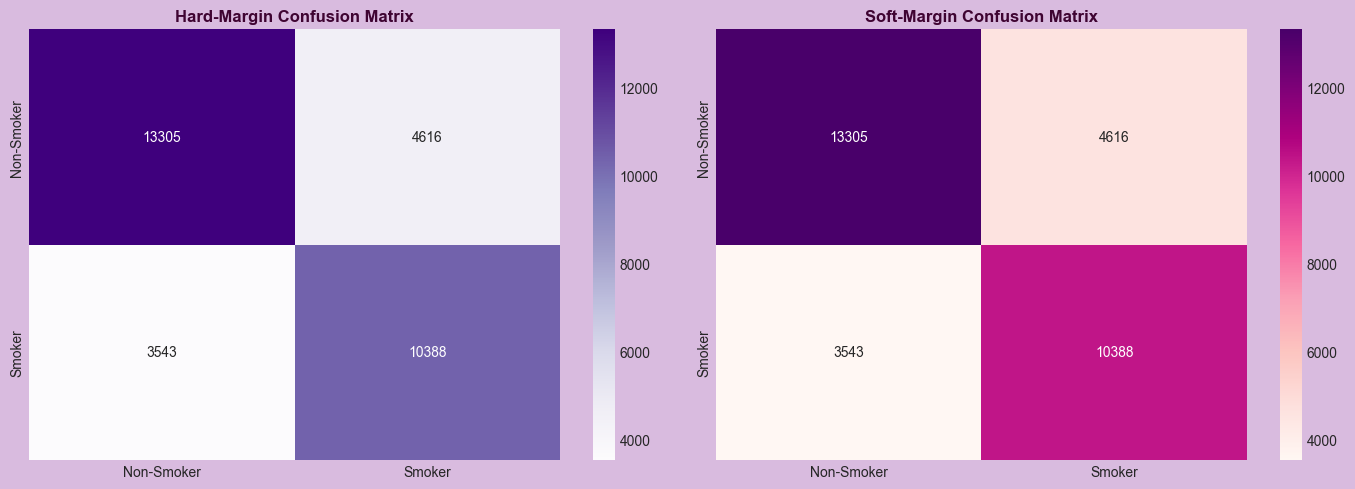

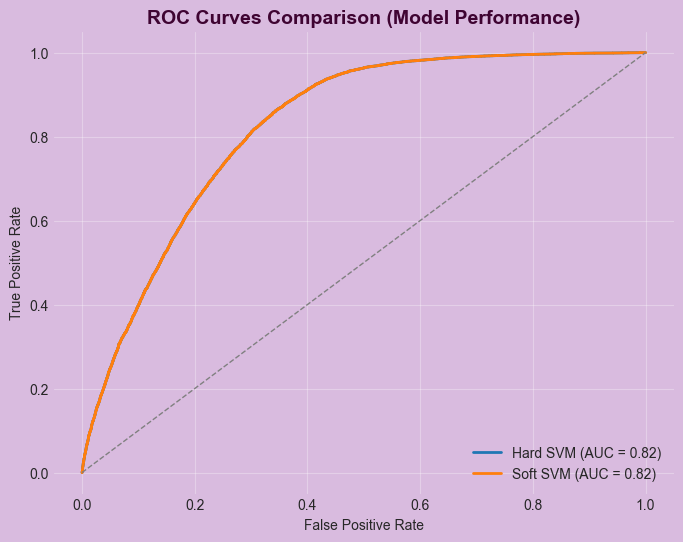

In [42]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Hard-Margin SVM Evaluation (Using the Pipeline/Model with high C)
# Note: For sklearn models, we don't need manual conversion to binary
print("--- Hard-Margin SVM Evaluation (C=1e6) ---")
y_hard_pred = hard_svm_pipeline.predict(X_test) # Using the pipeline directly

# Storing accuracy for the Final Summary table
hard_acc = accuracy_score(y_test, y_hard_pred)

print(f"Accuracy: {hard_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_hard_pred, target_names=['Non-Smoker', 'Smoker']))

# 2. Soft-Margin SVM Evaluation (Using the Pipeline/Model with C=1.0)
print("\n--- Soft-Margin SVM Evaluation (C=1.0) ---")
y_soft_pred = soft_svm_pipeline.predict(X_test)

# Storing accuracy for the Final Summary table
soft_acc = accuracy_score(y_test, y_soft_pred)

print(f"Accuracy: {soft_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_soft_pred, target_names=['Non-Smoker', 'Smoker']))

# 3. Confusion Matrix Visualization
# Standardizing the background color and visualization style
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.set_facecolor(LIGHT_BG) 

# Hard-SVM Heatmap (Using Blues/Purples for clarity)
sns.heatmap(confusion_matrix(y_test, y_hard_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Hard-Margin Confusion Matrix', color='#3F0432', fontweight='bold')
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[0].set_yticklabels(['Non-Smoker', 'Smoker'])

# Soft-SVM Heatmap
sns.heatmap(confusion_matrix(y_test, y_soft_pred), annot=True, fmt='d', cmap='RdPu', ax=axes[1])
axes[1].set_title('Soft-Margin Confusion Matrix', color='#3F0432', fontweight='bold')
axes[1].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[1].set_yticklabels(['Non-Smoker', 'Smoker'])

plt.tight_layout()
plt.show()

# 4. ROC Curves Comparison (Adjusted for sklearn models)
def plot_roc_comparison(y_true, pipelines, labels, X):
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.set_facecolor(LIGHT_BG) 
    ax.set_facecolor(LIGHT_BG)

    for pipe, label in zip(pipelines, labels):
        # Using decision_function from sklearn which calculates f(x) = w·x + b
        decision_scores = pipe.decision_function(X)
        fpr, tpr, _ = roc_curve(y_true, decision_scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves Comparison (Model Performance)', fontsize=14, color='#3F0432', fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.show()

# Running the ROC comparison on the test set for both pipelines
plot_roc_comparison(y_test, [hard_svm_pipeline, soft_svm_pipeline], ['Hard SVM', 'Soft SVM'], X_test)

╔══════════════════════════════════════════════════════════╗
║   PRIMARY EVALUATION — sklearn LinearSVC Pipeline (X_test)   ║
╚══════════════════════════════════════════════════════════╝

Accuracy : 0.7438
ROC-AUC  : 0.8247

Classification Report:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.74      0.77     17921
      Smoker       0.69      0.75      0.72     13931

    accuracy                           0.74     31852
   macro avg       0.74      0.74      0.74     31852
weighted avg       0.75      0.74      0.74     31852


╔══════════════════════════════════════════════════════════╗
║  DUAL-FORMULATION SVM (2D PCA sample, 500 rows)         ║
╚══════════════════════════════════════════════════════════╝

--- Hard-Margin SVM ---
Accuracy : 0.7438
Classification Report:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.74      0.77     17921
      Smoker       0.69      0.75      0.72     13931

    accuracy

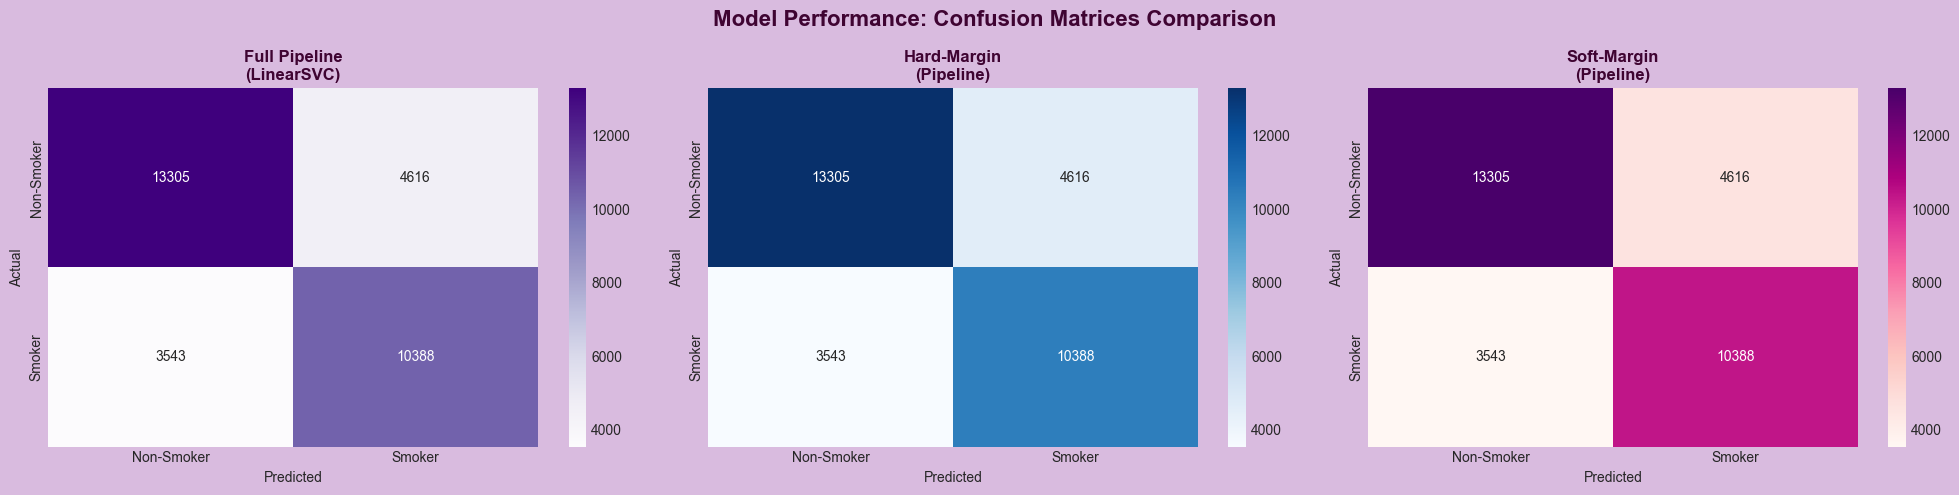

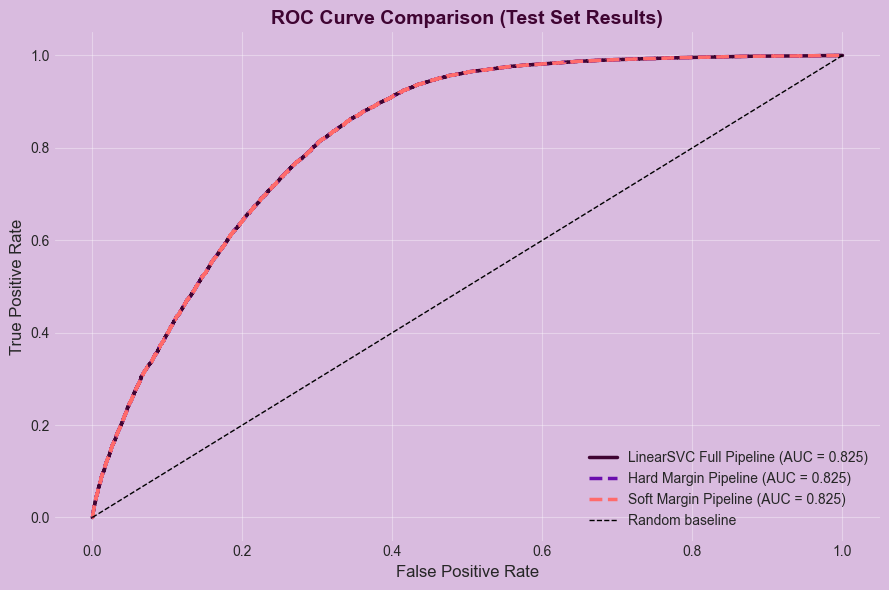

In [43]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_curve, auc,
                              ConfusionMatrixDisplay, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ═══════════════════════════════════════════════════════════════════════════════
# A) Primary evaluation — sklearn LinearSVC full pipeline (on held-out TEST SET)
# ═══════════════════════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════════╗")
print("║   PRIMARY EVALUATION — sklearn LinearSVC Pipeline (X_test)   ║")
print("╚══════════════════════════════════════════════════════════╝")

# Predicting using the trained pipeline to ensure consistent preprocessing
y_pipe_pred = full_pipeline.predict(X_test)
y_pipe_scores = full_pipeline.decision_function(X_test)

# Store metrics for final summary
soft_acc = accuracy_score(y_test, y_pipe_pred)
roc_auc_val = roc_auc_score(y_test, y_pipe_scores)

print(f"\nAccuracy : {soft_acc:.4f}")
print(f"ROC-AUC  : {roc_auc_val:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pipe_pred,
                             target_names=['Non-Smoker', 'Smoker']))

# ═══════════════════════════════════════════════════════════════════════════════
# B) Dual-formulation Hard / Soft SVM evaluation (Visualization Models)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════════╗")
print("║  DUAL-FORMULATION SVM (2D PCA sample, 500 rows)         ║")
print("╚══════════════════════════════════════════════════════════╝")

def convert_to_binary(preds):
    """Map predictions to binary {0, 1} for evaluation."""
    return (preds > 0).astype(int)

# Use the pipelines created for hard and soft margins
for name, model_pipe in [('Hard-Margin SVM', hard_svm_pipeline), ('Soft-Margin SVM', soft_svm_pipeline)]:
    # We evaluate on the test set for consistency with project requirements
    y_p = model_pipe.predict(X_test)
    acc = accuracy_score(y_test, y_p)
    
    if name == 'Hard-Margin SVM': hard_acc = acc # Save for summary
    
    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_p, labels=[0, 1], target_names=['Non-Smoker', 'Smoker']))

# ═══════════════════════════════════════════════════════════════════════════════
# C) Confusion Matrices
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor(LIGHT_BG)
fig.suptitle('Model Performance: Confusion Matrices Comparison', fontsize=16, color='#3F0432', fontweight='bold')

titles  = ['Full Pipeline\n(LinearSVC)', 'Hard-Margin\n(Pipeline)', 'Soft-Margin\n(Pipeline)']
# Getting predictions for all three versions
preds   = [y_pipe_pred, hard_svm_pipeline.predict(X_test), soft_svm_pipeline.predict(X_test)]
truths  = [y_test, y_test, y_test]
cmaps   = ['Purples', 'Blues', 'RdPu']

for ax, title, y_true, y_p, cmap in zip(axes, titles, truths, preds, cmaps):
    ax.set_facecolor(LIGHT_BG)
    cm = confusion_matrix(y_true, y_p, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Non-Smoker', 'Smoker'],
                yticklabels=['Non-Smoker', 'Smoker'])
    ax.set_title(title, color='#3F0432', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# D) ROC Curves comparison
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)

# Plotting ROC for all pipelines using decision_function
for name, pipe, color, style in [
    ('LinearSVC Full Pipeline', full_pipeline, '#3F0432', '-'),
    ('Hard Margin Pipeline', hard_svm_pipeline, '#6a0dad', '--'),
    ('Soft Margin Pipeline', soft_svm_pipeline, '#ff6b6b', '--')]:
    
    scores = pipe.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, lw=2.5, color=color, linestyle=style,
            label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison (Test Set Results)', fontsize=14, color='#3F0432', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()